# Timescales -- TRM model: `fixed_PA42`

Every dynamical/interaction timescale quoted in the paper, computed here and
nowhere else. Companion, additive analysis alongside the harmonic-fit
pipeline (see `harmonic_pipeline_fixed_PA42.ipynb` / `CLAUDE.md`) -- not
one of its Section 0 deliverables. All computation lives in `timescales.py`;
this notebook only imports it and displays figures, mirroring the split
already used by `harmonic_fit.py` / `harmonic_plots.py`. No science constant
appears outside `timescales.Config`; every ring parameter traces to
`fixed_PA42`'s own ringlog and `results/ring_results.ecsv`.

Other TRM models with a results/ring_results.ecsv already fit: TRM_paper.

**Sign convention.** `harmonic_fit.py`'s `s1` keeps the raw fit sign, and
`CLAUDE.md` 2.6.1 resolves -- for this galaxy, given the near side at
`theta = +90 deg` -- true outward `V_rad = -s1`. Every model below is
written with `V_R > 0` meaning outward (Wallin & Struck-Marcell 1994), so
`timescales.load_radial_velocities` flips the sign explicitly on read:
`v_R_outward = -s1`.

**Rotation-curve fit.** With only a handful of rings, an *interpolating*
natural cubic spline is forced exactly through ring-to-ring scatter that is
well within each ring's own `E_VROT` uncertainty. `timescales.
generate_kinematic_curve` fits a weighted low-order polynomial instead
(`cfg.rotation_curve_poly_order`, default 1/linear), which stays close to
flat where the data support it rather than chasing noise.

**What's new here vs. the earlier void-only notebook**: the NFW halo now
comes from `galpy` (verified against its own closed-form equations, Section
0), `R_ring` is measured directly from the moment-0 map (Section 1) instead
of being absent, and the pair (companion) timescales -- linear separation,
a full `galpy` orbit integration, and the debris free-expansion test -- are
implemented and will report real numbers as soon as `cfg.R_sep_kpc` /
`cfg.vsys_table_kms` / `cfg.bridge_pa_deg` / the debris measurements are
supplied; until then they skip cleanly (printed, not guessed).

## Config

The one cell in this notebook you are expected to edit -- normally just
`TRM_DIR`. The NFW halo (`M200_Msun`, `halo_concentration`, ...), the
epicyclic "kick" grid ranges, and the void's external RA/Dec corner
coordinates are `timescales.Config`'s science constants -- see
`timescales.py` for what each one means and where it comes from.

The pair (companion) fields -- `R_sep_kpc`, `vsys_table_kms`,
`bridge_pa_deg`, `debris_dR_kpc`/`debris_dV_kms` -- are commented out below:
no measurement of the companion's separation, systemic velocity, bridge
position angle, or debris extent exists anywhere in this repo (the ringlog
and moment maps cover only this galaxy). Sections 2.5-2.7 skip cleanly
(printed, not guessed) while they are `None`; uncomment and fill them in
once those measurements exist, and every cell below picks them up
automatically -- no other code changes needed.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import harmonic_fit as hf
import harmonic_plots as hp  # only for hp.custom_rcparams's mpl.rcParams.update side effect
import timescales as ts

repo_root = Path.cwd()
TRM_DIR = "fixed_PA42"  # which (already-fit) TRM model directory to run; see build_timescales_notebook.eligible_models

trm_dir = repo_root / TRM_DIR
cfg = ts.Config(
    trm_dir=trm_dir,
    ringlog_path=hf.find_ringlog(trm_dir),
    results_dir=trm_dir / "results",

    # -- Section 2.5/2.6/2.7: uncomment and fill in once these measurements exist --
    vsys_table_kms={
        "target": (4679, "Barolo VSYS, this TRM ringlog"),
        "intruder": (4873.14, "W20 vsys, mid"),
    },
    vsys_pair_label_a="target",
    vsys_pair_label_b="intruder",
    R_sep_kpc=54,               # projected separation to the companion
    bridge_pa_deg=135,           # measured bridge position angle on the sky
    debris_dR_kpc=19.0,           # debris expansion: sky-plane extent
    debris_dV_kms=300.0,           # debris expansion: LOS velocity difference
)
cfg

Config(trm_dir=PosixPath('/Users/24398082/projects/SM_harmonic_fit/fixed_PA42'), ringlog_path=PosixPath('/Users/24398082/projects/SM_harmonic_fit/fixed_PA42/PA_fixed_to_42.txt'), results_dir=PosixPath('/Users/24398082/projects/SM_harmonic_fit/fixed_PA42/results'), output_dir=PosixPath('/Users/24398082/projects/SM_harmonic_fit/fixed_PA42/results'), side='both', kpc_per_arcsec=0.32891247982574817, rotation_curve_poly_order=1, alpha=0.5, r_ref_kpc=15.0, v0_grid_max_kms=200.0, v0_grid_step_kms=1.0, t_grid_max_myr=400.0, t_grid_step_myr=1.0, M200_Msun=1900000000000.0, halo_concentration=10.0, halo_H0_kms_Mpc=70.0, halo_Om0=0.3, galpy_ro_kpc=8.0, galpy_vo_kms=220.0, void_center_hms=((17, 29, 9.588425), (-62, 26, 44.5182)), void_top_hms=((17, 29, 12.171038), (-62, 26, 27.349434)), void_bottom_hms=((17, 29, 11.630122), (-62, 27, 20.094748)), legacy_void_r_avg_kpc=13.88, legacy_void_dtheta_deg=105.75, shear_r_in_kpc=None, shear_r_out_kpc=None, vsys_table_kms={'target': (4679, 'Barolo VSYS, this

## 1. Inputs -- single source of truth

Rotation curve, its errors, PA, inclination, and `kpc_per_arcsec` all come
from `cfg.ringlog_path`. The radial-velocity array comes from
`results/ring_results.ecsv` (side="both", the primary weighting recorded in
its metadata), sign-flipped on read (see above).

In [2]:
rc = ts.load_rotation_curve(cfg.ringlog_path, order=cfg.rotation_curve_poly_order)
rv = ts.load_radial_velocities(cfg.results_dir, side=cfg.side)

print(f"ringlog = {cfg.ringlog_path.name}")
print(f"kpc_per_arcsec = {rc.kpc_per_arcsec:.5f}  INC = {rc.inc_deg:.3f} deg  P.A. = {rc.pa_deg:.3f} deg")
print(f"XPOS,YPOS = {rc.xpos_pix:.3f}, {rc.ypos_pix:.3f} pix\n")

print(f"{'R [kpc]':>10}{'VROT [km/s]':>14}{'-E_VROT1':>12}{'+E_VROT2':>12}")
for R, V, elo, ehi in zip(rc.radii_kpc, rc.v_kms, rc.v_err_lo, rc.v_err_hi):
    print(f"{R:10.3f}{V:14.3f}{elo:12.3f}{ehi:12.3f}")

print(f"\n{'ring':>6}{'R [kpc]':>10}{'s1 [km/s]':>12}{'v_R outward [km/s]':>20}{'sigma [km/s]':>14}")
for i, R, s1, vR, sig in zip(rv.ring_index, rv.radii_kpc, rv.s1_raw_kms, rv.v_R_outward_kms, rv.sigma_kms):
    print(f"{i:6d}{R:10.3f}{s1:12.3f}{vR:20.3f}{sig:14.3f}")

mapset = hf.load_maps(cfg.trm_dir / "maps")
cdelt1_sign = -1 if mapset.cdelt1_deg < 0 else (1 if mapset.cdelt1_deg > 0 else 0)
data_1mom = sorted((cfg.trm_dir / "maps").glob("*_1mom.fits"))
data_1mom = [f for f in data_1mom if "_local_" not in f.name][0]
from astropy.io import fits
header1 = fits.getheader(data_1mom)

/Users/24398082/projects/SM_harmonic_fit/harmonic_fit.py:237: UserWarning: PA_fixed_to_42.txt: Barolo's own RAD(Kpc)/RAD(arcs) implies kpc_per_arcsec=0.33904, which differs from the adopted (Planck18, source-distance) value 0.32891 by 3.1%. Barolo's internal cosmology/distance assumption is unknown; the adopted value is used for every kpc conversion in this project regardless -- see CLAUDE.md Section 3.
  warnings.warn(

ringlog = PA_fixed_to_42.txt
kpc_per_arcsec = 0.32891  INC = 50.560 deg  P.A. = 42.565 deg
XPOS,YPOS = 24.539, 26.310 pix

   R [kpc]   VROT [km/s]    -E_VROT1    +E_VROT2
    14.472       297.223      16.732      14.339
    17.663       295.973       6.523       6.564
    20.853       303.490       8.984       8.252
    24.044       307.541      12.379      12.856

  ring   R [kpc]   s1 [km/s]  v_R outward [km/s]  sigma [km/s]
     0    14.472       9.740              -9.740        10.208
     1    17.663      -0.819               0.819         5.422
     2    20.853 

## 2. Section 0: the NFW halo (`galpy`)

```
Phi(r) = -(G*M_s/r) * ln(1 + r/a)
M(r)   = M_s * (ln(1+r/a) - (r/a)/(1+r/a))
M_s    = M_200 / (ln(1+c) - c/(1+c)),   a = r_200/c
v_esc(r) = sqrt(-2*Phi(r))
```

`M_200`, the concentration `c`, and the cosmology (`H0`, `Om0`) are the only
halo inputs (`cfg.M200_Msun`, `cfg.halo_concentration`, ...); everything
else is derived. Before trusting any orbit computed with this potential
(Sections 2.6/2.9), `timescales.verify_nfw_potential` checks `galpy`'s
`NFWPotential` against these closed forms directly -- potential, enclosed
mass (including `M(r_200) == M_200` to `1e-6` relative), the
`mvir`/`conc`/`wrtcrit=True` constructor (checked against `wrtcrit=False`,
which uses a matter- rather than critical-density-referenced `r_200` and
gives a substantially different halo), and escape velocity -- and raises
with both values printed on any mismatch.

In [3]:
nfw_check = ts.verify_nfw_potential(cfg)
pot, Ms, a_scale, r200 = ts.build_nfw_potential(cfg)
print(f"\nM_s = {nfw_check['Ms_Msun']:.4e} Msun, a = {nfw_check['a_kpc']:.3f} kpc, r_200 = {nfw_check['r200_kpc']:.3f} kpc")

[timescales] NFW verification PASSED (Section 0.1, all 4 assertions): M_s=1.276192e+12 Msun, a=25.5489 kpc, r_200=255.4894 kpc
    potential rel diff=3.69e-16  mass rel diff=2.17e-16  mass(r200) rel diff=0.00e+00
    concentration-constructor: a rel diff=0.00e+00, r200 rel diff=0.00e+00 (wrtcrit=False gives a=38.17 kpc instead -- confirms wrtcrit=True matters)
    vesc rel diff=1.52e-10

M_s = 1.2762e+12 Msun, a = 25.549 kpc, r_200 = 255.489 kpc


## 3. Section 1: `R_ring` from the moment-0 map

```
Sigma_face_on(R) = <Sigma_observed>_theta(R) * cos(i)
```

The inclination-corrected, azimuthally-averaged HI surface-density profile
in concentric deprojected annuli, using `harmonic_fit.make_geometry` (the
same deprojection the harmonic ring fits use) on the data moment-0 map.
`R_ring` is the radius of the profile's maximum; its uncertainty is half the
annulus width (the adopted TRM's own ring width, so the radial binning
resolution matches the rest of this project).

**The annulus grid always starts at `R=0`**, independent of where
`fixed_PA42`'s own TRM rings happen to start (printed below -- the
harmonic fit was only run over that range, but the moment-0 map itself
covers the whole galaxy). If the innermost annuli come back with `n_pix=0`
(no finite moment-0 pixels), that is a genuine non-detection at the disc
centre -- expected for a collisional ring galaxy, whose HI is swept out
into the ring, leaving a real central hole -- not a gap introduced by
cropping the profile to the TRM's radial coverage. `R_ring`'s peak search
already runs over the full `R=0`-to-`R_max` grid and skips non-finite
annuli (`np.where(valid, sigma, -np.inf)`), so a genuine central hole
cannot shift `R_ring`; the full profile (not windowed around the peak) is
printed and plotted below so that is visible rather than asserted.

In [4]:
mom0_data, header0 = ts.load_data_mom0(cfg.trm_dir / "maps")
ringlog_width_arcsec = hf.read_ringlog(cfg.ringlog_path).meta["ring_width_arcsec"]
sigma_profile = ts.measure_R_ring(rc, mom0_data, header0, cdelt1_sign, ringlog_width_arcsec)

print(f"R_ring = {sigma_profile.R_ring_kpc:.2f} +/- {sigma_profile.R_ring_err_kpc:.2f} kpc "
      f"({sigma_profile.R_ring_arcsec:.1f} arcsec, annulus {sigma_profile.ring_index}, "
      f"annulus width {sigma_profile.annulus_width_arcsec:.2f} arcsec)")
print(f"TRM ring coverage starts at {rc.radii_kpc.min():.2f} kpc -- the Sigma_HI profile below starts at R=0 regardless.")

n_blank = int(np.sum(sigma_profile.n_pix == 0))
if n_blank:
    print(f"{n_blank} innermost annuli have n_pix=0 (no moment-0 detection) -- a real central hole, not a cropped range.")

print(f"\n{'annulus':>8}{'R [kpc]':>10}{'Sigma_HI':>14}{'+/- err':>12}{'n_pix':>8}")
for i in range(len(sigma_profile.R_kpc)):
    marker = "  <-- R_ring" if i == sigma_profile.ring_index else ("  (no detection)" if sigma_profile.n_pix[i] == 0 else "")
    print(f"{i:8d}{sigma_profile.R_kpc[i]:10.3f}{sigma_profile.sigma[i]:14.5f}{sigma_profile.sigma_err[i]:12.5f}{sigma_profile.n_pix[i]:8d}{marker}")

R_ring = 17.55 +/- 1.60 kpc (53.4 arcsec, annulus 5, annulus width 9.70 arcsec)
TRM ring coverage starts at 14.47 kpc -- the Sigma_HI profile below starts at R=0 regardless.
2 innermost annuli have n_pix=0 (no moment-0 detection) -- a real central hole, not a cropped range.

 annulus   R [kpc]      Sigma_HI     +/- err   n_pix
       0     1.595           nan         nan       0  (no detection)
       1     4.786           nan         nan       0  (no detection)
       2     7.976       0.00216     0.00072       2
       3    11.167       0.00689     0.00169      14
       4    14.357       0.01440     0.00140      80
       5    17.547       0.02812     0.00169     120  <-- R_ring
       6    20.738       0.02625     0.00146     137
       7    23.928       0.01553     0.00132     115
       8    27.119       0.00943     0.00132      48
       9    30.309       0.00405     0.00065      24
      10    33.500       0.00268     0.00073       4
      11    36.690       0.00274     0.00013

## Figure 2: `Sigma_HI(R)` profile, `R_ring` marked

(Numbered to match the spec's figure list; displayed here since it belongs
right after the measurement above.) The x-axis is pinned to start at `R=0`
regardless of where the plotted points begin, and the central non-detection
(if any) is shaded explicitly, so the true radial hole is distinguishable
from an axis that merely autoscaled to the first data point.

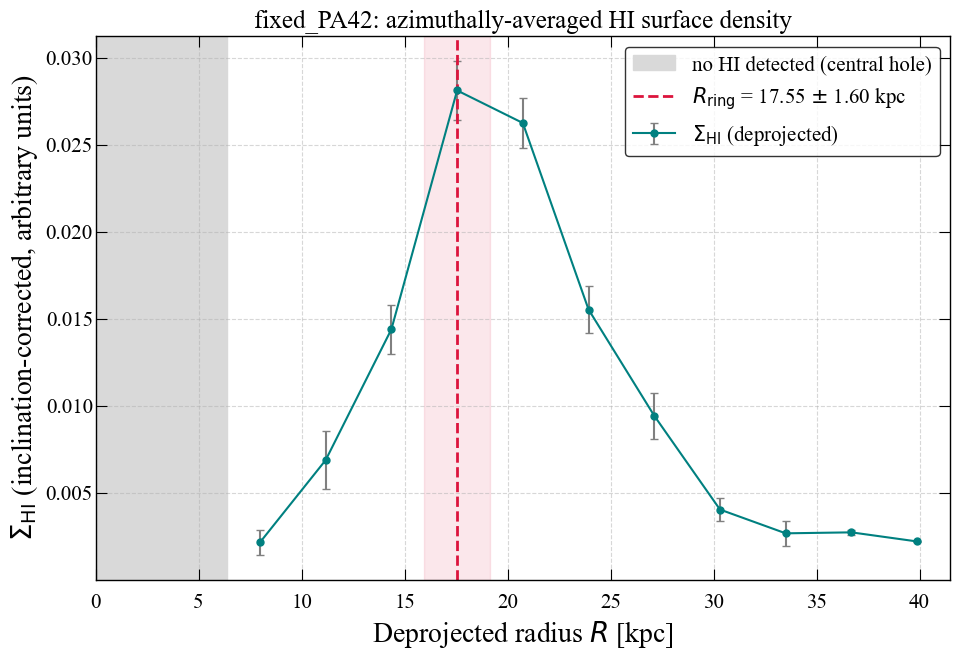

In [5]:
def fig_sigma_hi_profile(sigma_profile):
    fig, ax = plt.subplots(figsize=(10, 7))
    valid = np.isfinite(sigma_profile.sigma)
    ax.errorbar(sigma_profile.R_kpc[valid], sigma_profile.sigma[valid], yerr=sigma_profile.sigma_err[valid],
                fmt="o-", color="teal", ecolor="gray", capsize=3, markersize=5, lw=1.5, label=r"$\Sigma_{\rm HI}$ (deprojected)")

    no_detection = sigma_profile.n_pix == 0
    if np.any(no_detection) and np.any(valid):
        R_first_valid = sigma_profile.R_edges_kpc[np.argmax(valid)]
        ax.axvspan(0, R_first_valid, color="0.85", zorder=0, label="no HI detected (central hole)")

    ax.axvline(sigma_profile.R_ring_kpc, color="crimson", linestyle="--", lw=2,
               label=f"$R_{{\\rm ring}}$ = {sigma_profile.R_ring_kpc:.2f} $\\pm$ {sigma_profile.R_ring_err_kpc:.2f} kpc")
    ax.axvspan(sigma_profile.R_ring_kpc - sigma_profile.R_ring_err_kpc,
               sigma_profile.R_ring_kpc + sigma_profile.R_ring_err_kpc, color="crimson", alpha=0.1)
    ax.set_xlabel("Deprojected radius $R$ [kpc]")
    ax.set_ylabel(r"$\Sigma_{\rm HI}$ (inclination-corrected, arbitrary units)")
    ax.set_xlim(0, sigma_profile.R_edges_kpc[-1])
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="best", frameon=True)
    ax.set_title(f"{TRM_DIR}: azimuthally-averaged HI surface density")
    fig.tight_layout()
    return fig

fig_sigma_hi_profile(sigma_profile)
None

## 4. Section 2.3: crescent void (already implemented)

```
T_phi = 2*pi*R_void/V_c,   t = T_phi * (dtheta / 360)
```

Deprojects the void's top/bottom sky corners about the void's own reference
point using the same rotation/handedness convention `make_geometry` uses
internally (`harmonic_fit.deproject_pixel_offsets`) -- not a second,
independently-defined deprojection. Per Wallin & Struck-Marcell (1994) Sec
3.3.3, the void continues to expand after formation, so treating `dtheta` as
constant makes the interaction timescale an **upper limit**. Also reported:
the same calculation using the nearest *measured* ring's `V_c` instead of
the fitted/extrapolated curve, as a systematic.

In [6]:
void = ts.void_geometry(cfg, rc, header1, cdelt1_sign)
void_nearest = ts.void_interaction_nearest_vc(rc, void)

print(f"{'':>18}{'R_avg [kpc]':>14}{'Delta theta [deg]':>20}")
print(f"{'corrected':>18}{void.r_avg_kpc:14.2f}{void.dtheta_deg:20.2f}")
print(f"{'legacy (buggy)':>18}{void.legacy_r_avg_kpc:14.2f}{void.legacy_dtheta_deg:20.2f}")
print(f"\nLocal v_c at R_avg (fitted curve) = {void.v_c_void_kms:.2f} km/s   T_phi = {void.T_phi_void_myr:.1f} Myr")
print(f"Fraction of orbit spanned by the void = {void.fraction_of_orbit:.3f} ({void.fraction_of_orbit*100:.1f}%)")
print(f"Interaction timescale (UPPER LIMIT, fitted curve) = {void.t_interaction_myr:.1f} Myr")
print(f"Interaction timescale (UPPER LIMIT, systematic: nearest measured ring {void_nearest['ring_index']}, "
      f"V_c={void_nearest['v_c_kms']:.1f} km/s) = {void_nearest['t_interaction_myr']:.1f} Myr")

/Users/24398082/projects/SM_harmonic_fit/timescales.py:238: UserWarning: void R_avg: evaluating the rotation-curve fit 1.039 kpc below the innermost ring (14.472 kpc) -- dv/dR (and kappa) is extrapolated, not measured.
  warnings.warn(

                     R_avg [kpc]   Delta theta [deg]
         corrected         13.43              101.26
    legacy (buggy)         13.88              105.75

Local v_c at R_avg (fitted curve) = 288.52 km/s   T_phi = 286.0 Myr
Fraction of orbit spanned by the void = 0.281 (28.1%)
Interaction timescale (UPPER LIMIT, fitted curve) = 80.5 Myr
Interaction timescale (UPPER LIMIT, systematic: nearest measured ring 0, V_c=297.2 km/s) = 78.1 Myr


## Figure 1: rotation curve, `R_void`, and `R_ring`

Weighted least-squares polynomial fit through the adopted ringlog's
`VROT(R)` (not an interpolating spline -- see above); ring points with their
asymmetric error bars; the void's and the ring's deprojected radii marked.
The region beyond the ringlog's radial coverage (where `dv/dR` -- and
therefore `kappa` -- is extrapolated, not measured) is shaded.

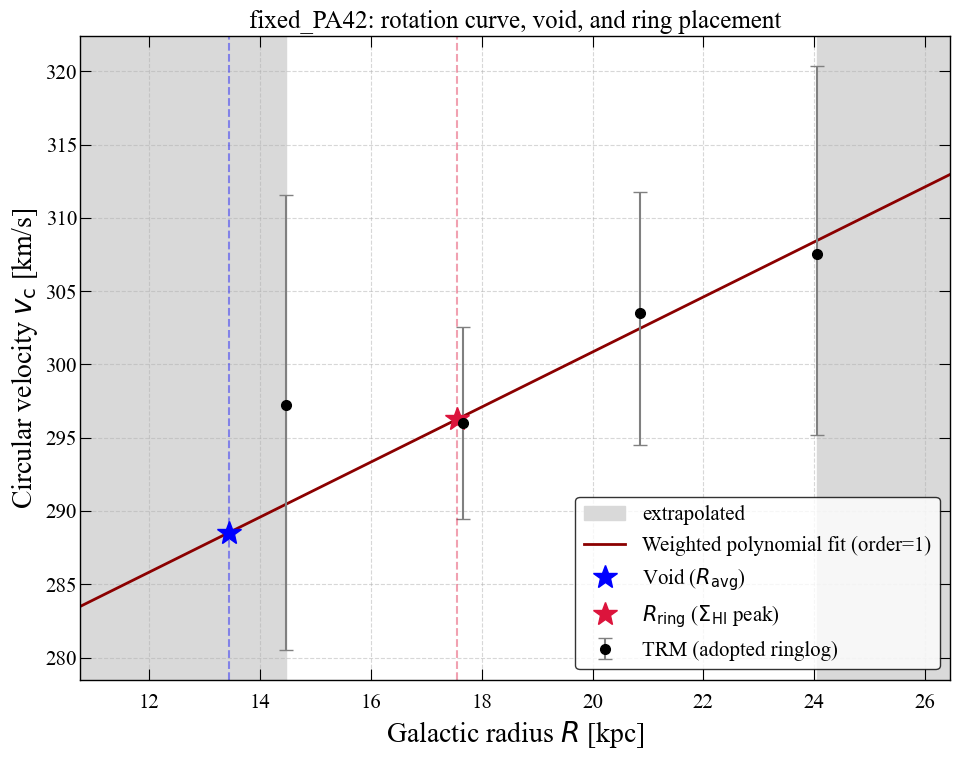

In [7]:
def fig_rotation_curve(rc, void, sigma_profile, cfg):
    r_min, r_max = rc.radii_kpc.min(), rc.radii_kpc.max()
    r_lo_plot = min(r_min, void.r_avg_kpc, sigma_profile.R_ring_kpc) * 0.8
    r_hi_plot = max(r_max, void.r_avg_kpc, sigma_profile.R_ring_kpc) * 1.1
    R_grid = np.linspace(r_lo_plot, r_hi_plot, 300)
    v_grid = rc.curve(R_grid)

    fig, ax = plt.subplots(figsize=(10, 8))
    if r_lo_plot < r_min:
        ax.axvspan(r_lo_plot, r_min, color="0.85", zorder=0, label="extrapolated")
    if r_hi_plot > r_max:
        ax.axvspan(r_max, r_hi_plot, color="0.85", zorder=0)
    ax.plot(R_grid, v_grid, color="darkred", lw=2,
            label=f"Weighted polynomial fit (order={cfg.rotation_curve_poly_order})")
    ax.errorbar(rc.radii_kpc, rc.v_kms, yerr=[rc.v_err_lo, rc.v_err_hi], fmt="o", color="black",
                ecolor="gray", capsize=5, elinewidth=1.5, markersize=7, label="TRM (adopted ringlog)")
    ax.plot(void.r_avg_kpc, void.v_c_void_kms, "*", color="blue", markersize=18, label=r"Void ($R_{\rm avg}$)")
    ax.axvline(void.r_avg_kpc, color="blue", linestyle="--", alpha=0.4)
    ax.plot(sigma_profile.R_ring_kpc, rc.curve(sigma_profile.R_ring_kpc), "*", color="crimson", markersize=18,
             label=r"$R_{\rm ring}$ ($\Sigma_{\rm HI}$ peak)")
    ax.axvline(sigma_profile.R_ring_kpc, color="crimson", linestyle="--", alpha=0.4)

    ax.set_xlabel("Galactic radius $R$ [kpc]")
    ax.set_ylabel(r"Circular velocity $v_{\mathrm{c}}$ [km/s]")
    ax.set_xlim(r_lo_plot, r_hi_plot)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="lower right", frameon=True)
    ax.set_title(f"{TRM_DIR}: rotation curve, void, and ring placement")
    fig.tight_layout()
    return fig

fig_rotation_curve(rc, void, sigma_profile, cfg)
None

## 5. Section 2.1: epicyclic and orbital periods (already implemented)

```
Omega = V_c / R,   kappa^2 = 2*Omega^2 + 2*Omega*dV_c/dR
T_phi = 2*pi/Omega,   T_kappa = 2*pi/kappa
```

Reported per ring, not as a single global number -- `T_kappa/2` varies by up
to 50% ring to ring, so a single number for the whole ring is never quoted.

In [8]:
T_phi_ring, T_kappa_ring, T_kappa_half_ring, dv_dR_ring = ts.t_kappa_half_per_ring(rc)
print(f"{'R [kpc]':>10}{'T_phi [Myr]':>14}{'T_kappa [Myr]':>16}{'T_kappa/2 [Myr]':>18}{'dV_c/dR [km/s/kpc]':>22}")
for R, tphi, tk, tkh, dv in zip(rc.radii_kpc, T_phi_ring, T_kappa_ring, T_kappa_half_ring, dv_dR_ring):
    print(f"{R:10.3f}{tphi:14.1f}{tk:16.1f}{tkh:18.1f}{dv:22.3f}")

   R [kpc]   T_phi [Myr]   T_kappa [Myr]   T_kappa/2 [Myr]    dV_c/dR [km/s/kpc]
    14.472         306.1           207.0             103.5                 1.878
    17.663         366.0           245.5             122.7                 1.878
    20.853         423.6           281.8             140.9                 1.878
    24.044         478.9           316.3             158.1                 1.878


## 6. Section 2.2: ring turnaround (new)

```
t = T_kappa(R_ring) / 2
```

Evaluated at `R_ring` (Section 1), with its uncertainty propagated through
`T_kappa`. A dissipative gas ring lags the collisionless (stellar) caustic
that this formally predicts, so this is a **lower limit** relative to the
stellar-population turnaround time, not an exact match to it.

In [9]:
t_ring_turnaround, t_ring_turnaround_err = ts.ring_turnaround_timescale(rc, sigma_profile.R_ring_kpc, sigma_profile.R_ring_err_kpc)
print(f"t_ring_turnaround = {t_ring_turnaround:.1f} +/- {t_ring_turnaround_err:.1f} Myr "
      f"(ESTIMATE, lower limit vs. the stellar/collisionless prediction)")

t_ring_turnaround = 122.1 +/- 9.4 Myr (ESTIMATE, lower limit vs. the stellar/collisionless prediction)


## 7. Section 2.4: disk shear (new)

```
Delta_Omega = Omega(R_in) - Omega(R_out),   t_shear = 1 / Delta_Omega
```

`t_shear` is the time for one radian of differential rotation to accumulate
between `R_in` and `R_out` (default: the ringlog's own innermost/outermost
ring) -- an **upper limit** on the age of any *coherent material* feature
spanning that range. It does **not** apply to the ring itself, which this
project treats as a wave (epicyclic) pattern, not advected material -- see
Section 2.2 above for the ring's own clock. Evaluated at the adopted age
(the min/max of every `Myr`-valued estimate computed in this notebook, see
Section 10 below) to report the shear angle actually accumulated.

In [10]:
# Computed once as a placeholder pass to get an approximate adopted-age
# midpoint for the shear-angle report; the authoritative adopted range
# (Section 10) is recomputed after every timescale below has been evaluated.
shear_preview = ts.disk_shear_timescale(cfg, rc)
print(f"t_shear (1 radian) = {shear_preview['t_shear_myr']:.1f} Myr  "
      f"(UPPER LIMIT on coherent-material age over [{shear_preview['r_in_kpc']:.1f}, {shear_preview['r_out_kpc']:.1f}] kpc; "
      "does not apply to the ring, which is a wave pattern)")

t_shear (1 radian) = 135.0 Myr  (UPPER LIMIT on coherent-material age over [14.5, 24.0] kpc; does not apply to the ring, which is a wave pattern)


## 8. Section 3 (infrastructure): the epicyclic ("kick") chi2 grid

```
V_R(R, t) = V0 * (R/r_ref)^(-alpha) * sin(kappa(R)*t)
```

`alpha` is fixed at `cfg.alpha` (Wallin & Struck-Marcell 1994, Sec 3.1),
never fitted -- four rings cannot constrain three free parameters.
`chi2(V0, t)` is evaluated on a deterministic 2D grid (no optimiser
anywhere in this path); its minimum is the "two-parameter epicyclic model"
compared against the `V_rad=0` null in Section 2.8 below.

In [11]:
grid = ts.epicyclic_chi2_grid(cfg, rv, rc)
print(f"chi2 minimum on the (V0, t) grid: {grid.chi2_min:.2f} at V0={grid.V0_at_min:.1f} km/s, t={grid.t_at_min:.1f} Myr")

chi2 minimum on the (V0, t) grid: 4.30 at V0=4.0 km/s, t=234.0 Myr


## 9. Section 2.8: radial-oscillation exclusion (already partly implemented)

```
chi2_null/dof = sum_i (V_rad_i/sigma_i)^2 / N_annuli
delta_chi2    = chi2_null - chi2_min(V0, t grid)
significance_i = V_rad_i / sigma_i
```

**No amplitude limit in pc is quoted.** The statistical limit on `V0` is
swamped by the PA systematic (`harmonic_fit.pa_degeneracy_slope`, with
`phi`'s own formal uncertainty read directly from the PA scan
`harmonic_fit.py` already computed, `results/scans.npz` -- never re-derived
or hardcoded here) and by beam dilution (the beam is wider than the ring);
both are printed alongside the statistical error below so the comparison is
explicit.

In [12]:
exclusion = ts.radial_oscillation_exclusion(cfg, rv, rc, grid)

[timescales] Section 2.8: chi2/dof (null V_rad=0) = 4.74/4 = 1.184; delta_chi2 (vs. 2-param epicyclic grid min) = 0.44
    ring 0: V_rad/sigma = -0.95   PA systematic = -3.984 km/s/deg * 7.50 deg (TRM PA scan) = 29.88 km/s   vs. statistical sigma = 10.21 km/s
    ring 1: V_rad/sigma = +0.15   PA systematic = -4.057 km/s/deg * 3.50 deg (TRM PA scan) = 14.20 km/s   vs. statistical sigma = 5.42 km/s
    ring 2: V_rad/sigma = +0.22   PA systematic = -4.108 km/s/deg * 9.12 deg (TRM PA scan) = 37.48 km/s   vs. statistical sigma = 6.63 km/s
    ring 3: V_rad/sigma = -1.94   PA systematic = -4.159 km/s/deg * 11.00 deg (TRM PA scan) = 45.75 km/s   vs. statistical sigma = 6.83 km/s
[timescales] No amplitude limit in pc is quoted: the statistical limit on V0 is swamped by the PA systematic and by beam dilution (beam wider than the ring), shown above.


## 10. Section 2.9: Wallin & Struck-Marcell (1994) epoch conversion (new)

```
t_WSM = f * T_kappa(eps)
```

Their model times are in units of `2*pi/omega(eps)`, the epicyclic period
**at the softening length** `eps` -- not at any physical ring radius. Their
AM 1724-like epochs are `f = 0.45` and `0.56` (their Figs. 5a, 6). Tabulated
over `cfg.wsm_eps_grid_kpc` so the sensitivity to the (necessarily
uncertain) `eps` identification is visible; `eps = R_ring` is marked
separately since their Sec 4.2 supports it (best morphological match when
the ring has propagated to about one softening length, near the
rotation-curve turnover).

In [13]:
wsm = ts.wsm_epoch_conversion(cfg, rc, sigma_profile.R_ring_kpc)
print(f"{'eps [kpc]':>10}{'T_kappa(eps) [Myr]':>20}" + "".join(f"{'t_WSM f=' + str(f):>16}" for f in wsm["epochs"]))
for row in wsm["eps_grid_table"]:
    line = f"{row['eps_kpc']:10.2f}{row['T_kappa_eps_myr']:20.1f}"
    for f in wsm["epochs"]:
        key = f"t_WSM_f{f}_myr"
        line += f"{row[key]:16.1f}"
    print(line)
row = wsm["eps_equals_R_ring"]
line = f"{row['eps_kpc']:10.2f}{row['T_kappa_eps_myr']:20.1f}"
for f in wsm["epochs"]:
    key = f"t_WSM_f{f}_myr"
    line += f"{row[key]:16.1f}"
print(line + "   <-- eps = R_ring (Sec 4.2 morphological match)")

/Users/24398082/projects/SM_harmonic_fit/timescales.py:238: UserWarning: WSM epoch conversion (eps grid): evaluating the rotation-curve fit 4.472 kpc below the innermost ring (14.472 kpc) -- dv/dR (and kappa) is extrapolated, not measured.
  warnings.warn(

/Users/24398082/projects/SM_harmonic_fit/timescales.py:243: UserWarning: WSM epoch conversion (eps grid): evaluating the rotation-curve fit 0.956 kpc beyond the outermost ring (24.044 kpc) -- dv/dR (and kappa) is extrapolated, not measured.
  warnings.warn(

 eps [kpc]  T_kappa(eps) [Myr]    t_WSM f=0.45    t_WSM f=0.56
     10.00               149.1            67.1            83.5
     15.00               213.5            96.1           119.6
     20.00               272.3           122.5           152.5
     25.00               326.2           146.8           182.7
     17.55               244.1           109.8           136.7   <-- eps = R_ring (Sec 4.2 morphological match)


## 11. Sections 2.5-2.7: the pair (companion)

Skip cleanly (printed, not guessed) until `cfg.R_sep_kpc` / `cfg.vsys_table_kms`
/ `cfg.bridge_pa_deg` / the debris measurements are supplied in the Config
cell above.

**2.5 -- pair separation, linear:**
```
t_lin = (R_sep / dV_sys) * cot(theta) * 977.8   [Myr]
```
`dV_sys` is computed from `cfg.vsys_table_kms` (never hand-typed -- the
manuscript previously carried inconsistent values, 207 km/s in one place,
209 in another, 240 implied by the source table, precisely because this
difference was never computed from one named source). The naive
`theta = 45 deg` case (`cot=1`, the value the manuscript previously quoted)
and the disk-normal `theta = i` case are both reported explicitly, with the
sensitivity `dt/t = dtheta/(sin(theta)*cos(theta))` and the bridge-PA
orientation check (`|bridge_pa - (phi+90)| < 5 deg`) that licenses
`theta = i`.

**2.6 -- pair orbit integration (`galpy`):**
```
r_now = R_sep/sin(theta),   v_now = dV_sys/cos(theta)
E     = v_now^2/2 + Phi(r_now)
v(r)  = sqrt(2*(E - Phi(r)))
t     = integral_{r_peri}^{r_now} dr/v(r)
```
`Phi` from the same `galpy` NFW potential verified in Section 2 above. `t`
for `r_peri` in `cfg.r_peri_scan_kpc` (0, 6, 12 kpc, sensitivity), and a full
`theta` scan tabulating `r_now`, `v_now`, `t`, and `v/v_esc`.

**2.7 -- debris expansion and the free-expansion test:**
```
grad_debris = dV_debris/dR_debris,   grad_pair = dV_sys/R_sep
```
Free expansion from a common origin requires these to match; if they don't,
free expansion is **rejected** and `t_debris` is reported for completeness
only, never as a clock.

In [14]:
pair_linear = ts.pair_separation_linear(cfg, rc)
if pair_linear is not None:
    print(f"\nR_sep = {pair_linear['R_sep_kpc']:.2f} kpc, dV_sys = {pair_linear['dV_sys_kms']:.1f} km/s")
    print(f"t (naive, theta=45 deg)      = {pair_linear['t_naive_theta45_myr']:.1f} Myr   "
          f"(sensitivity: {pair_linear['sensitivity_naive_per_step']:.1%} per {pair_linear['sensitivity_step_deg']:.0f} deg)")
    print(f"t (disk-normal, theta=i={pair_linear['theta_i_deg']:.2f} deg) = {pair_linear['t_disk_normal_theta_i_myr']:.1f} Myr   "
          f"(sensitivity: {pair_linear['sensitivity_disk_normal_per_step']:.1%} per {pair_linear['sensitivity_step_deg']:.0f} deg)")

[timescales] dV_sys = VSYS['intruder'] - VSYS['target'] = (4873.1 km/s, W20 vsys, mid) - (4679.0 km/s, Barolo VSYS, this TRM ringlog) = 194.1 km/s
[timescales] Bridge orientation check: measured PA=135.00 deg vs. expected (disc minor axis, phi+90=132.56 deg) -- delta=2.44 deg -- PASSED (theta=i requires delta < 5 deg)

R_sep = 54.00 kpc, dV_sys = 194.1 km/s
t (naive, theta=45 deg)      = 272.0 Myr   (sensitivity: 17.5% per 5 deg)
t (disk-normal, theta=i=50.56 deg) = 223.7 Myr   (sensitivity: 17.8% per 5 deg)


In [15]:
pair_orbit = ts.pair_orbit_report(cfg, rc, target_t_myr=t_ring_turnaround)
if pair_orbit is not None:
    print(f"\nr_peri sensitivity scan (theta=i):")
    for row in pair_orbit["r_peri_scan"]:
        print(f"    r_peri={row['r_peri_kpc']:5.1f} kpc  ->  t={row['t_myr']:7.1f} Myr")
    print(f"\nt at theta=i (disk-normal) = {pair_orbit['t_at_theta_i_myr']:.1f} Myr")
    if pair_orbit["theta_v_eq_vesc_deg"] is not None:
        print(f"theta at which v=v_esc (bound/unbound boundary) = {pair_orbit['theta_v_eq_vesc_deg']:.1f} deg "
              "-- t there is a LOWER bound on t if the pair is bound")
    if pair_orbit["theta_matching_target_deg"] is not None:
        print(f"theta needed to match the ring-turnaround estimate ({t_ring_turnaround:.1f} Myr) = "
              f"{pair_orbit['theta_matching_target_deg']:.1f} deg")

    # Cross-check: quadrature vs. a full galpy Orbit integration of the same
    # radial orbit, at theta=i (Section 4, acceptance test 3).
    r_now_i, v_now_i = ts.pair_orbit_r_now_v_now(pair_linear["R_sep_kpc"] if pair_linear else cfg.R_sep_kpc,
                                                  pair_orbit["dV_sys_kms"], rc.inc_deg)
    t_orbit_crosscheck = ts.orbit_time_via_galpy_orbit_myr(pot, cfg.r_peri_kpc, r_now_i, v_now_i, cfg.galpy_ro_kpc, cfg.galpy_vo_kms)
    print(f"\ngalpy Orbit cross-check at theta=i: t={t_orbit_crosscheck:.2f} Myr vs. quadrature "
          f"t={pair_orbit['t_at_theta_i_myr']:.2f} Myr "
          f"(rel diff {abs(t_orbit_crosscheck - pair_orbit['t_at_theta_i_myr'])/pair_orbit['t_at_theta_i_myr']:.2%})")

[timescales] dV_sys = VSYS['intruder'] - VSYS['target'] = (4873.1 km/s, W20 vsys, mid) - (4679.0 km/s, Barolo VSYS, this TRM ringlog) = 194.1 km/s

r_peri sensitivity scan (theta=i):
    r_peri=  0.0 kpc  ->  t=  172.6 Myr
    r_peri=  6.0 kpc  ->  t=  161.7 Myr
    r_peri= 12.0 kpc  ->  t=  150.1 Myr

t at theta=i (disk-normal) = 150.4 Myr
theta at which v=v_esc (bound/unbound boundary) = 65.7 deg -- t there is a LOWER bound on t if the pair is bound
theta needed to match the ring-turnaround estimate (122.1 Myr) = 57.0 deg

galpy Orbit cross-check at theta=i: t=150.12 Myr vs. quadrature t=150.40 Myr (rel diff 0.19%)


## Figure 4: `t(theta)` and `v/v_esc(theta)` for the pair orbit

Twin axes: `t(theta)` and `v/v_esc(theta)`, with the unbound region
(`v/v_esc >= 1`) shaded, the disk-normal (`theta=i`) value marked, and the
ring-turnaround estimate marked for comparison. This figure carries the
orbital-geometry argument in the paper.

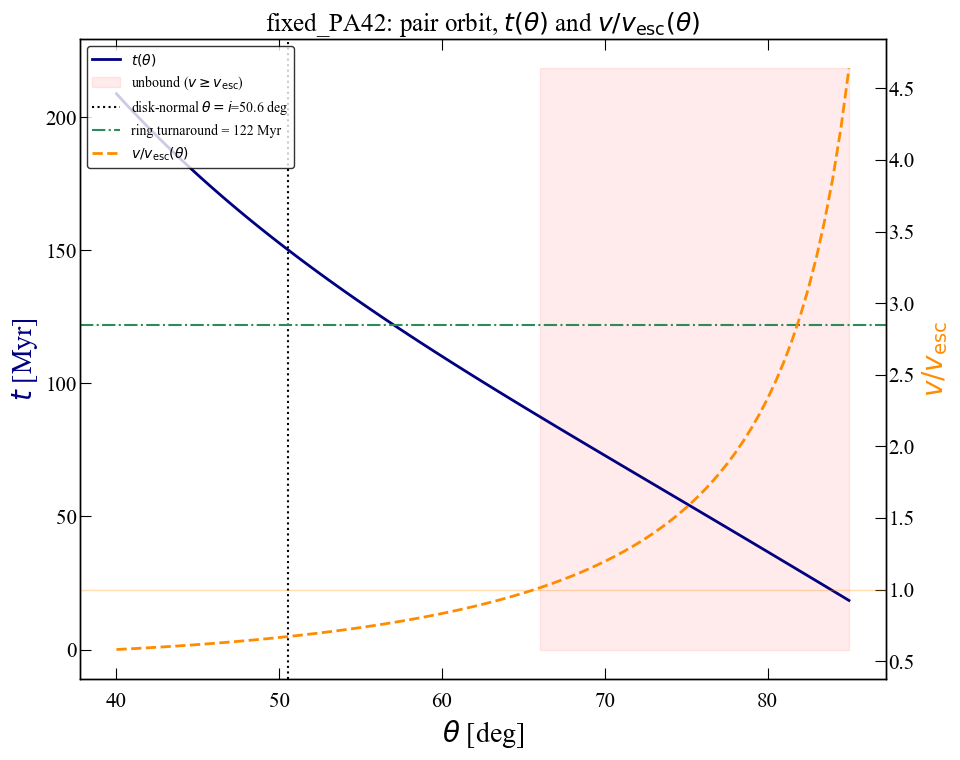

In [16]:
def fig_pair_orbit_theta(pair_orbit, t_ring_turnaround):
    if pair_orbit is None:
        print("Skipped: pair_orbit is None (R_sep_kpc/vsys_table_kms not supplied).")
        return None
    fig, ax1 = plt.subplots(figsize=(10, 8))
    ax2 = ax1.twinx()

    theta = pair_orbit["theta_grid_deg"]
    ax1.plot(theta, pair_orbit["t_grid_myr"], color="navy", lw=2, label="$t(\\theta)$")
    ax2.plot(theta, pair_orbit["v_over_vesc_grid"], color="darkorange", lw=2, linestyle="--", label="$v/v_{\\rm esc}(\\theta)$")

    unbound = pair_orbit["v_over_vesc_grid"] >= 1.0
    if np.any(unbound):
        ax1.fill_between(theta, 0, ax1.get_ylim()[1], where=unbound, color="red", alpha=0.08, label="unbound ($v \\geq v_{\\rm esc}$)")

    ax1.axvline(pair_orbit["theta_i_deg"], color="black", linestyle=":", lw=1.5,
                label=f"disk-normal $\\theta=i$={pair_orbit['theta_i_deg']:.1f} deg")
    ax1.axhline(t_ring_turnaround, color="seagreen", linestyle="-.", lw=1.5,
                label=f"ring turnaround = {t_ring_turnaround:.0f} Myr")

    ax1.set_xlabel(r"$\theta$ [deg]")
    ax1.set_ylabel("$t$ [Myr]", color="navy")
    ax2.set_ylabel(r"$v/v_{\rm esc}$", color="darkorange")
    ax2.axhline(1.0, color="darkorange", alpha=0.3, lw=1)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10, frameon=True)
    ax1.set_title(f"{TRM_DIR}: pair orbit, $t(\\theta)$ and $v/v_{{\\rm esc}}(\\theta)$")
    fig.tight_layout()
    return fig

fig_pair_orbit_theta(pair_orbit, t_ring_turnaround)
None

In [17]:
debris = ts.debris_free_expansion_test(cfg, rc)

[timescales] dV_sys = VSYS['intruder'] - VSYS['target'] = (4873.1 km/s, W20 vsys, mid) - (4679.0 km/s, Barolo VSYS, this TRM ringlog) = 194.1 km/s
[timescales] Section 2.7: grad_debris=15.7895 km/s/kpc, grad_pair=3.5952 km/s/kpc, ratio=4.392 -- free expansion is REJECTED if this ratio is far from 1. t_debris=50.9 Myr is reported for completeness ONLY -- NOT a clock.


## 12. Adopted age range, and the disk-shear angle at that age

The min/max of every `Myr`-valued central estimate computed above (ring
turnaround, void interaction, WSM at `eps=R_ring`, and -- once supplied --
the pair-orbit `theta=i` estimate). Not hand-typed: recomputed from whatever
was actually evaluated in this run.

In [18]:
results = ts.run(cfg)
adopted = results["adopted_age_range"]
if adopted is not None:
    print(f"Adopted age range: {adopted['lo_myr']:.1f} Myr ({adopted['lo_source']}) -- "
          f"{adopted['hi_myr']:.1f} Myr ({adopted['hi_source']})")
    for name, val in adopted["contributors"].items():
        print(f"    {name}: {val:.1f} Myr")

shear = results["disk_shear"]
if shear["shear_angle_at_adopted_age_deg"] is not None:
    print(f"\nShear angle accumulated over [{shear['r_in_kpc']:.1f}, {shear['r_out_kpc']:.1f}] kpc "
          f"at the adopted age's midpoint: {shear['shear_angle_at_adopted_age_deg']:.1f} deg "
          f"(t_shear for 1 radian = {shear['t_shear_myr']:.1f} Myr)")

/Users/24398082/projects/SM_harmonic_fit/harmonic_fit.py:237: UserWarning: PA_fixed_to_42.txt: Barolo's own RAD(Kpc)/RAD(arcs) implies kpc_per_arcsec=0.33904, which differs from the adopted (Planck18, source-distance) value 0.32891 by 3.1%. Barolo's internal cosmology/distance assumption is unknown; the adopted value is used for every kpc conversion in this project regardless -- see CLAUDE.md Section 3.
  warnings.warn(

[timescales] NFW verification PASSED (Section 0.1, all 4 assertions): M_s=1.276192e+12 Msun, a=25.5489 kpc, r_200=255.4894 kpc
    potential rel diff=3.69e-16  mass rel diff=2.17e-16  mass(r200) rel diff=0.00e+00
    concentration-constructor: a rel diff=0.00e+00, r200 rel diff=0.00e+00 (wrtcrit=False gives a=38.17 kpc instead -- confirms wrtcrit=True matters)
    vesc rel diff=1.52e-10
/Users/24398082/projects/SM_harmonic_fit/timescales.py:238: UserWarning: void R_avg: evaluating the rotation-curve fit 1.039 kpc below the innermost ring (14.472 kpc) -- dv/dR (and kapp

## Figure 3: `T_phi`, `T_kappa`, `T_kappa/2` vs. radius, with the adopted age

The adopted age range (Section 12) shown as a horizontal band, alongside
each per-ring clock.

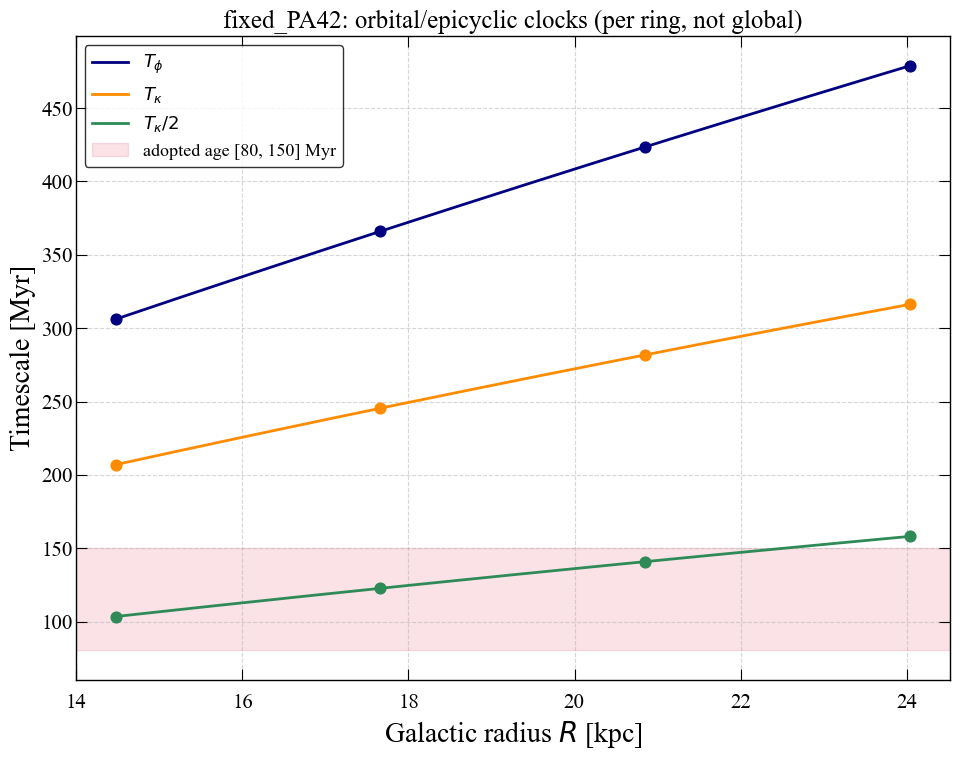

In [19]:
def fig_clocks(rc, results):
    R_grid = np.linspace(rc.radii_kpc.min(), rc.radii_kpc.max(), 200)
    Omega_g, kappa_g = ts.calculate_frequencies(R_grid, rc.curve)
    Tphi_g, Tk_g = ts.calculate_timescales(Omega_g, kappa_g)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.plot(R_grid, Tphi_g, color="navy", lw=2, label=r"$T_\phi$")
    ax.plot(R_grid, Tk_g, color="darkorange", lw=2, label=r"$T_\kappa$")
    ax.plot(R_grid, Tk_g / 2.0, color="seagreen", lw=2, label=r"$T_\kappa/2$")
    ax.scatter(rc.radii_kpc, results["per_ring_clocks"]["T_phi_myr"], color="navy", s=60, zorder=5)
    ax.scatter(rc.radii_kpc, results["per_ring_clocks"]["T_kappa_myr"], color="darkorange", s=60, zorder=5)
    ax.scatter(rc.radii_kpc, results["per_ring_clocks"]["T_kappa_half_myr"], color="seagreen", s=60, zorder=5)

    adopted = results["adopted_age_range"]
    if adopted is not None:
        ax.axhspan(adopted["lo_myr"], adopted["hi_myr"], color="crimson", alpha=0.12,
                   label=f"adopted age [{adopted['lo_myr']:.0f}, {adopted['hi_myr']:.0f}] Myr")

    ax.set_xlabel("Galactic radius $R$ [kpc]")
    ax.set_ylabel("Timescale [Myr]")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="best", frameon=True, fontsize=13)
    ax.set_title(f"{TRM_DIR}: orbital/epicyclic clocks (per ring, not global)")
    fig.tight_layout()
    return fig

fig_clocks(rc, results)
None

## Section 3 (spec): output -- `timescales.json` and the Table 2 summary

Every quantity above, as `{value, unit, type, assumption}`, written to
`results/timescales.json`; the Table 2 summary (Method, Observable,
`t [Myr]`, Type, Limiting assumption) is generated directly from that same
dict, never hand-typed.

In [20]:
ts.write_results(cfg, results)
rows = ts.build_summary_table(results)
ts.print_summary_table(rows)
import pandas as pd
pd.DataFrame(rows)

[timescales] Wrote /Users/24398082/projects/SM_harmonic_fit/fixed_PA42/results/timescales.json

[timescales] Table 2 -- timescale summary:
Method                  Observable                 t [Myr]      Type         Limiting assumption                                                                                                                   
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Epicyclic (ring)        T_kappa(R_ring)/2          122.05       estimate     T_kappa(R_ring)/2; lower limit relative to the stellar (collisionless) prediction                                                     
Crescent void           T_phi * dtheta/360         80.46        upper_limit  constant dtheta (Wallin & Struck-Marcell 1994 Sec 3.3.3: the hole keeps expanding)                                                    
Pair orbit (g

,Method,Observable,t [Myr],Type,Limiting assumption
0,Epicyclic (ring),T_kappa(R_ring)/2,122.050462,estimate,T_kappa(R_ring)/2; lower limit relative to the...
1,Crescent void,T_phi * dtheta/360,80.455636,upper_limit,constant dtheta (Wallin & Struck-Marcell 1994 ...
2,Pair orbit (galpy),"radial infall, theta=i",150.402709,estimate,"radial orbit, theta=i, r_peri=12.0 kpc (Wallin..."
3,Pair orbit (galpy),v=v_esc bound,89.384741,lower_limit,v=v_esc at theta=65.7 deg -- t is a LOWER boun...
4,Debris expansion,(dR/dV)*cot(i) [REJECTED],50.94013,rejected,free-expansion gradients differ by a factor of...
5,WSM epoch (eps=R_ring),f=0.45-0.56,109.8-136.7,estimate,"f=0.45-0.56, eps=R_ring (Wallin & Struck-Marce..."
6,Disk shear,1/Delta_Omega (1 radian),135.012167,upper_limit,upper limit on coherent-material age over [14....


## Figure 5: timescale comparison

Every `Myr`-valued estimate as a horizontal bar on one time axis,
distinguishing estimates/upper limits/rejected values by colour, with the
adopted range shaded.

/var/folders/t5/5qtfxw710_v7c4s8jsygdjhs8mpz9v/T/ipykernel_7981/1229382447.py:25: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.85, edgecolor="black") for c in color_by_type.values()]



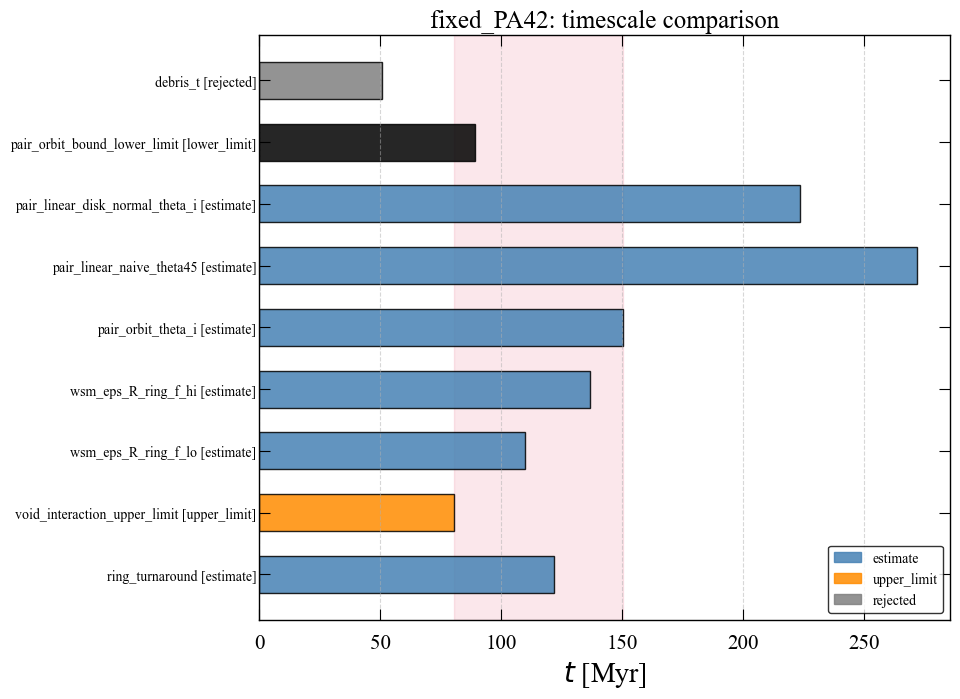

In [21]:
def fig_timescale_comparison(results):
    quantities = results["quantities"]
    myr_items = [(k, q) for k, q in quantities.items() if q["unit"] == "Myr"]
    if not myr_items:
        print("No Myr-valued quantities to plot.")
        return None

    color_by_type = {"estimate": "steelblue", "upper_limit": "darkorange", "rejected": "gray"}
    fig, ax = plt.subplots(figsize=(10, 0.6 * len(myr_items) + 2))
    labels = []
    for i, (key, q) in enumerate(myr_items):
        ax.barh(i, q["value"], color=color_by_type.get(q["type"], "black"), alpha=0.85,
                edgecolor="black", height=0.6)
        labels.append(f"{key} [{q['type']}]")

    adopted = results["adopted_age_range"]
    if adopted is not None:
        ax.axvspan(adopted["lo_myr"], adopted["hi_myr"], color="crimson", alpha=0.1, zorder=0,
                   label=f"adopted age [{adopted['lo_myr']:.0f}, {adopted['hi_myr']:.0f}] Myr")

    ax.set_yticks(range(len(myr_items)))
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel("$t$ [Myr]")
    ax.grid(True, axis="x", linestyle="--", alpha=0.5)
    handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.85, edgecolor="black") for c in color_by_type.values()]
    ax.legend(handles, list(color_by_type.keys()), loc="lower right", frameon=True, fontsize=10)
    ax.set_title(f"{TRM_DIR}: timescale comparison")
    fig.tight_layout()
    return fig

fig_timescale_comparison(results)
None

## Closing summary

- **`R_ring`** (Section 3, Figure 2) is measured directly from the moment-0
  map's deprojected surface-density profile, not asserted.
- **The NFW halo is `galpy`'s `NFWPotential`**, verified against its own
  closed-form equations (potential, mass, `M(r_200)==M_200`, the
  `wrtcrit=True` concentration constructor, escape velocity) before any
  orbit is integrated with it.
- **Ring turnaround** (`T_kappa(R_ring)/2`) is a lower limit relative to the
  stellar/collisionless prediction -- a dissipative gas ring lags the
  caustic.
- **Void interaction** is an upper limit (Wallin & Struck-Marcell 1994 Sec
  3.3.3: the hole keeps expanding after formation), reported both with the
  fitted rotation curve and with the nearest measured ring's `V_c` as a
  systematic.
- **Disk shear** is an upper limit on the age of *coherent material*
  spanning `[r_in, r_out]` -- it does not apply to the ring itself, a wave
  pattern.
- **No amplitude limit in pc is quoted** for the radial-oscillation
  exclusion (Section 9) -- the statistical limit is swamped by the PA
  systematic and beam dilution, both shown explicitly.
- **The pair (companion) timescales** -- linear separation, the full
  `galpy` orbit integration, and the debris free-expansion test -- report
  real numbers once `cfg.R_sep_kpc` / `cfg.vsys_table_kms` /
  `cfg.bridge_pa_deg` / the debris measurements are supplied; until then
  they skip cleanly rather than guessing.
- **The debris gradient is never used as a clock** -- only as a
  free-expansion consistency test against the pair's own separation/
  velocity gradient.
- **`fixed_PA42`'s Table 2** (immediately above Figure 5) is generated
  directly from `results/timescales.json`, never hand-typed -- nothing in
  this notebook (or the paper) can drift out of sync with what
  `timescales.py` actually computed.